In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pygments.lexers import factor

In [72]:
data = pd.read_parquet('../data/processed/data.parquet')

In [73]:
data = data.sort_values(by=['eom', 'id'], ascending = True)

In [74]:
data['ret'].min()

np.float64(-0.999993846)

In [75]:
for col in data.columns.to_list():
    print(col)

id
date
eom
source_crsp
size_grp
obs_main
exch_main
primary_sec
gvkey
iid
permno
permco
excntry
curcd
fx
common
comp_tpci
crsp_shrcd
comp_exchg
crsp_exchcd
adjfct
shares
me_lag1
gics
sic
naics
ff49
me_company
prc
prc_local
dolvol
ret
ret_lag_dif
ret_exc_lead1m
enterprise_value
book_equity
assets
sales
net_income
bidask
prc_high
prc_low
tvol
div1m_me
div3m_me
div6m_me
div12m_me
divspc1m_me
divspc12m_me
chcsho_1m
chcsho_3m
chcsho_6m
chcsho_12m
eqnpo_1m
eqnpo_3m
eqnpo_6m
eqnpo_12m
ret_1_0
ret_2_0
ret_3_0
ret_3_1
ret_6_0
ret_6_1
ret_9_0
ret_9_1
ret_12_0
ret_12_1
ret_12_7
ret_18_1
ret_24_1
ret_24_12
ret_36_1
ret_36_12
ret_48_12
ret_48_1
ret_60_1
ret_60_12
ret_60_36
seas_1_1an
seas_1_1na
seas_2_5an
seas_2_5na
seas_6_10an
seas_6_10na
seas_11_15an
seas_11_15na
seas_16_20an
seas_16_20na
at_gr1
ca_gr1
nca_gr1
lt_gr1
cl_gr1
ncl_gr1
be_gr1
pstk_gr1
debt_gr1
sale_gr1
cogs_gr1
sga_gr1
opex_gr1
capx_gr1
inv_gr1
at_gr3
ca_gr3
nca_gr3
lt_gr3
cl_gr3
ncl_gr3
be_gr3
pstk_gr3
debt_gr3
sale_gr3
cogs_gr3
sga

In [76]:
len(data.columns)

438

In [77]:
port = pd.read_csv('../data/backtest/xgboost_expanding/portfolios.csv')
port

,id,leg,weight,predicted_ret,realized_ret,eom
0,100885001,long,0.003842,0.010433,0.164196,1986-01-31
1,100898901,long,0.005577,0.010433,-0.102857,1986-01-31
2,100425301,long,0.002771,0.010433,-0.048774,1986-01-31
3,100427301,long,0.004975,0.010433,0.140689,1986-01-31
4,100882901,long,0.003940,0.010433,0.133802,1986-01-31
...,...,...,...,...,...,...
223735,100120901,short,-0.015145,0.006186,0.073095,2025-10-31
223736,102683902,short,-0.002814,0.006186,0.049370,2025-10-31
223737,103503501,short,-0.002973,0.006186,-0.084191,2025-10-31
223738,112138201,short,-0.013591,0.006186,0.017377,2025-10-31


In [78]:
algo_ret = pd.read_csv('../data/backtest/xgboost_expanding/monthly_returns.csv')
algo_ret

,eom,ic_pearson,ic_spearman,best_iteration,n_train,scoring_year,train_end_year,long_ret,short_ret,qspread,net_qspread,turnover,n_long,n_short,n_universe
0,1986-01-31,0.077784,0.078461,1,149779,1986,1985,0.056219,0.049447,0.006772,0.004772,1.000000,169,169,1692
1,1986-02-28,0.072079,0.065237,1,149779,1986,1985,0.035672,0.034870,0.000802,-0.001084,0.942719,169,169,1698
2,1986-03-31,-0.013384,-0.011755,1,149779,1986,1985,-0.023080,0.010991,-0.034071,-0.035972,0.950577,174,174,1745
3,1986-04-30,0.031536,0.035425,1,149779,1986,1985,0.042299,0.039560,0.002739,0.000991,0.874037,175,175,1756
4,1986-05-31,0.074762,0.073527,1,149779,1986,1985,0.019547,-0.026485,0.046032,0.044605,0.713916,176,176,1765
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
473,2025-06-30,0.024943,0.038619,16,1751432,2025,2024,0.018965,0.004040,0.014925,0.013774,0.575157,178,178,1785
474,2025-07-31,0.107710,0.125157,16,1751432,2025,2024,0.087692,0.037240,0.050452,0.048886,0.783249,178,178,1780
475,2025-08-31,0.099990,0.034035,16,1751432,2025,2024,0.010484,-0.011518,0.022002,0.020563,0.719228,179,179,1796
476,2025-09-30,-0.009550,-0.030001,16,1751432,2025,2024,-0.021804,-0.019868,-0.001937,-0.003408,0.735662,180,180,1807


In [79]:
idx = np.where(algo_ret['net_qspread'] == algo_ret['net_qspread'].max())
idx

(array([169]),)

<Axes: >

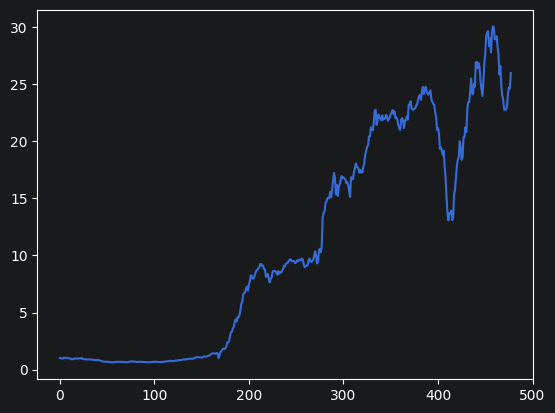

In [80]:
(1 + algo_ret['net_qspread']).cumprod().plot()

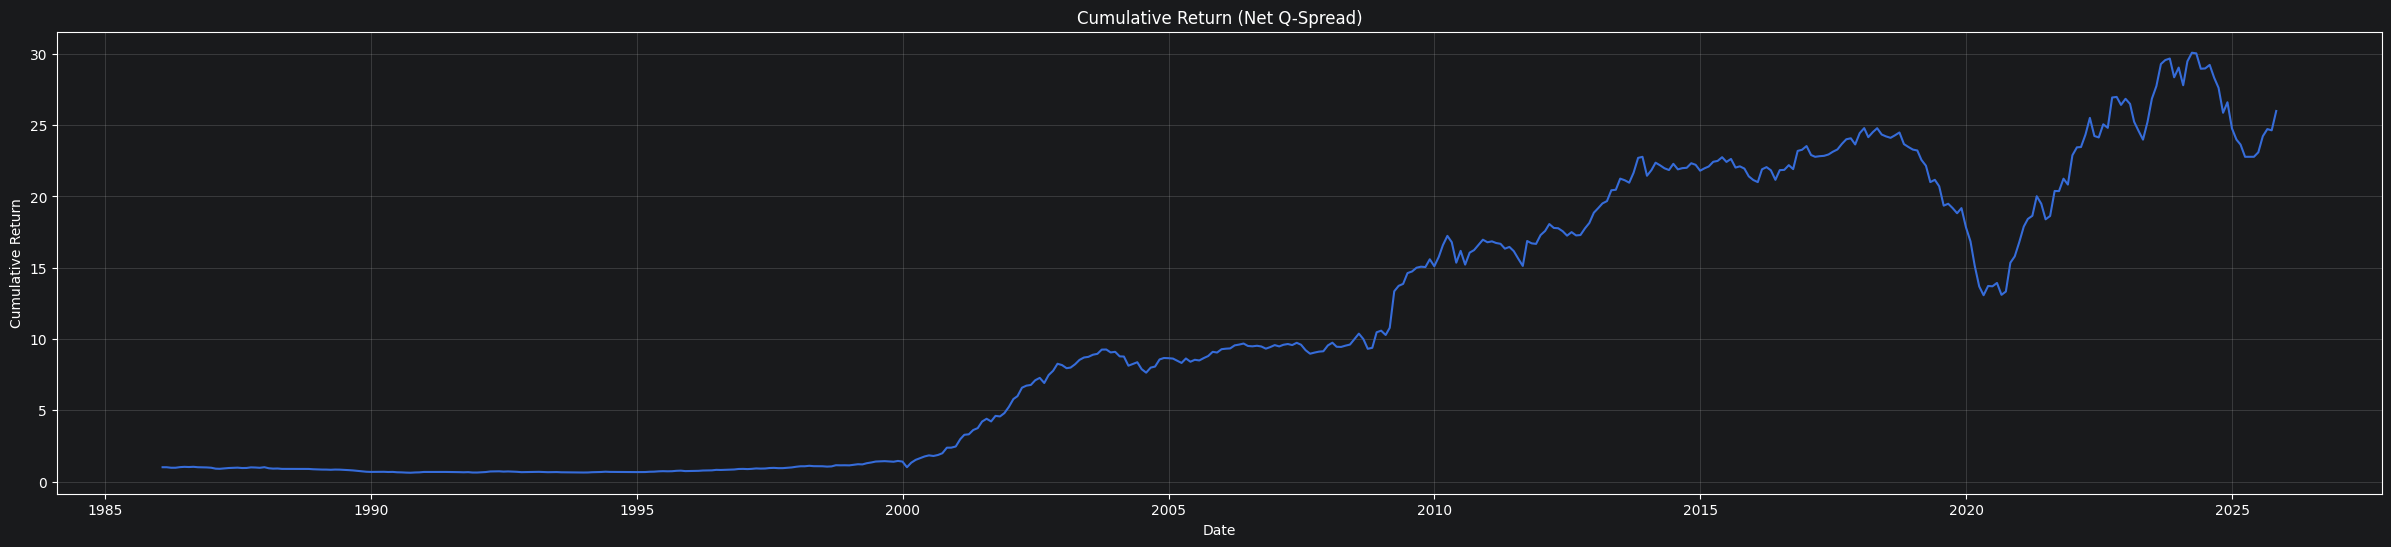

In [81]:
# Ensure datetime
algo_ret['eom'] = pd.to_datetime(algo_ret['eom'])

# Sort by date
xg_boost_ret = algo_ret.sort_values('eom')

# Cumulative return
series = (1 + algo_ret['net_qspread']).cumprod()

# Plot (wider figure)
plt.figure(figsize=(30, 6))
plt.plot(algo_ret['eom'], series)

plt.title('Cumulative Return (Net Q-Spread)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.grid(True, alpha=0.3)

plt.show()

In [82]:
factor_df = pd.read_csv('../data/backtest/xgboost_expanding/feature_importance.csv',  on_bad_lines="skip")
factor_df

,Unnamed: 0,me_company,prc,prc_local,dolvol,ret,enterprise_value,book_equity,assets,sales,...,dstnetis_mev,dbnetis_mev,netis_mev,fincf_mev,eq_dur,mispricing_mgmt,mispricing_perf,age,qmj_prof,qmj_safety
0,1986-01-31,0.006734,0.006257,0.010621,0.009351,0.015579,0.006758,0.010129,0.007881,0.0,...,0.008731,0.0,0.005705,0.0,0.006035,0.0,0.019351,0.006744,0.006107,0.015711
1,1986-02-28,0.006734,0.006257,0.010621,0.009351,0.015579,0.006758,0.010129,0.007881,0.0,...,0.008731,0.0,0.005705,0.0,0.006035,0.0,0.019351,0.006744,0.006107,0.015711
2,1986-03-31,0.006734,0.006257,0.010621,0.009351,0.015579,0.006758,0.010129,0.007881,0.0,...,0.008731,0.0,0.005705,0.0,0.006035,0.0,0.019351,0.006744,0.006107,0.015711
3,1986-04-30,0.006734,0.006257,0.010621,0.009351,0.015579,0.006758,0.010129,0.007881,0.0,...,0.008731,0.0,0.005705,0.0,0.006035,0.0,0.019351,0.006744,0.006107,0.015711
4,1986-05-31,0.006734,0.006257,0.010621,0.009351,0.015579,0.006758,0.010129,0.007881,0.0,...,0.008731,0.0,0.005705,0.0,0.006035,0.0,0.019351,0.006744,0.006107,0.015711
5,1986-06-30,0.006734,0.006257,0.010621,0.009351,0.015579,0.006758,0.010129,0.007881,0.0,...,0.008731,0.0,0.005705,0.0,0.006035,0.0,0.019351,0.006744,0.006107,0.015711
6,1986-07-31,0.006734,0.006257,0.010621,0.009351,0.015579,0.006758,0.010129,0.007881,0.0,...,0.008731,0.0,0.005705,0.0,0.006035,0.0,0.019351,0.006744,0.006107,0.015711
7,1986-08-31,0.006734,0.006257,0.010621,0.009351,0.015579,0.006758,0.010129,0.007881,0.0,...,0.008731,0.0,0.005705,0.0,0.006035,0.0,0.019351,0.006744,0.006107,0.015711
8,1986-09-30,0.006734,0.006257,0.010621,0.009351,0.015579,0.006758,0.010129,0.007881,0.0,...,0.008731,0.0,0.005705,0.0,0.006035,0.0,0.019351,0.006744,0.006107,0.015711
9,1986-10-31,0.006734,0.006257,0.010621,0.009351,0.015579,0.006758,0.010129,0.007881,0.0,...,0.008731,0.0,0.005705,0.0,0.006035,0.0,0.019351,0.006744,0.006107,0.015711


In [83]:
for factor in factor_df:
    print(factor)

Unnamed: 0
me_company
prc
prc_local
dolvol
ret
enterprise_value
book_equity
assets
sales
net_income
bidask
prc_high
prc_low
tvol
chcsho_1m
chcsho_3m
chcsho_6m
chcsho_12m
eqnpo_1m
eqnpo_3m
eqnpo_6m
eqnpo_12m
ret_1_0
ret_2_0
ret_3_0
ret_3_1
ret_6_0
ret_6_1
ret_9_0
ret_9_1
ret_12_0
ret_12_1
ret_12_7
seas_1_1an
at_gr1
ca_gr1
nca_gr1
lt_gr1
cl_gr1
ncl_gr1
be_gr1
debt_gr1
sale_gr1
cogs_gr1
opex_gr1
capx_gr1
inv_gr1
cash_gr1a
inv_gr1a
rec_gr1a
ppeg_gr1a
lti_gr1a
debtst_gr1a
ap_gr1a
txp_gr1a
debtlt_gr1a
txditc_gr1a
coa_gr1a
col_gr1a
cowc_gr1a
ncoa_gr1a
ncol_gr1a
nncoa_gr1a
oa_gr1a
ol_gr1a
fna_gr1a
fnl_gr1a
nfna_gr1a
gp_gr1a
ebitda_gr1a
ebit_gr1a
ope_gr1a
ni_gr1a
nix_gr1a
dp_gr1a
fincf_gr1a
ocf_gr1a
fcf_gr1a
nwc_gr1a
eqnetis_gr1a
dltnetis_gr1a
dbnetis_gr1a
netis_gr1a
eqnpo_gr1a
tax_gr1a
eqbb_gr1a
eqis_gr1a
div_gr1a
eqpo_gr1a
capx_gr1a
be_gr1a
capx_at
spi_at
xido_at
nri_at
gp_sale
ebitda_sale
ebit_sale
pi_sale
ni_sale
nix_sale
ocf_sale
fcf_sale
gp_at
ebitda_at
ebit_at
fi_at
cop_at
ni_at
ope_be
n